# Partie 1

*AUDIN Loric, FAIVRE Elio, PERREY PRATO Joan, RUFFIN Axel*

## 1.Contexte
L’ADEME (Agence de l’Environnement et de la Maîtrise de l’Énergie) souhaiterait ralentir le réchauffement climatique en essayant de diviser par 4 les émissions d'ici 2050 pour la France. Pour cela, elle aimerait optimiser la logistique du transport en limitant au maximum les déplacements et la consommation des véhicules lors des livraisons.

Nous, CesiCDP, devons les aider à atteindre les objectifs et permettre de trouver les trajets optimaux rapidement dans toute la France. Il leur faudrait une solution pour résoudre leur problème d'optimisation ainsi que des études de celles-ci.

## 2. Identification du problème

Ce problème est modélisé comme une variante du Traveling Salesman Problem.

En intégrant des contraintes supplémentaires, notamment des fenêtres temporelles, on obtient une variante appelée Traveling Salesman Problem with Time Windows.

Pour répondre aux objectifs de l'ADEME, notre modèle ne se contente pas de chercher le chemin le plus court car il doit intégrer les réalités logistiques via deux contraintes majeures :

- Coût ou restriction de passage sur certaines arêtes : Contrairement à un modèle simplifié où toutes les routes sont accessibles, notre modèle intègre des pondérations variables sur les arêtes ($c_{ij}$). Cela nous permet de modéliser des travaux programmés ou des restrictions de gabarit. Certaines arêtes peuvent être totalement interdites (coût M), forçant l'algorithme à recalculer un détour optimal.

- Fenêtres temporelles (Time Windows) : Chaque ville $i$ est associée à un intervalle de temps $[e_i, l_i]$. Le véhicule doit impérativement arriver avant l'heure limite $l_i$. S'il arrive avant l'heure d'ouverture $e_i$, il doit patienter, ce qui impacte le temps total de la tournée. Cette contrainte est capitale pour modéliser les horaires de livraison en zone urbaine ou les créneaux de réception des clients.

Pour la représentation du réseau routier national sous forme de graphe, nous considérerons que les noeuds sont des villes et les arêtes sont les routes.


## 3. Définition mathématique du problème

### Formulation précise

On établit le problème suivant :
Soit un graphe non orienté $G(S, A)$ avec : <br>
- $S = \{s_0, s_1, \dots, s_n\}$ est l'ensemble des sommets,<br>
- $A$ l'ensemble des arêtes,<br>
- $c_{ij}$ le coût de la traversée de l'arête $(s_i, s_j)$, il représente la distance en km.
- $d_{ij}$ le temps de trajet nécéssaire pour parcourir l'arête $(s_i, s_j)$.
- $[e_i, l_i]$ la fenêtre temporelle de la ville $s_i$, où $e_i$ est l'heure d'arrivée au plus tôt et $l_i$ l'heure au plus tard. ($e$ pour "earliest" et $l$ pour "latest")

### Fonction objectif

$$ \quad Z = \sum_{(i,j) \in A} c_{ij} \cdot x_{ij}$$

$$
\text{PL :}\begin{cases}
\text{Minimiser } Z = \displaystyle\sum_{i \in S} \displaystyle\sum_{j \in S} c_{ij} \cdot x_{ij} \\
\\
\text{Sujet à :} \\
\displaystyle\sum_{j \in S, j \neq i} x_{ij} = 1, \quad \forall i \in S & \text{(Chaque ville est quittée une fois)} \\
\displaystyle\sum_{i \in S, i \neq j} x_{ij} = 1, \quad \forall j \in S & \text{(Chaque ville est visitée une fois)} \\
t_i + d_{ij} - t_j \le M(1 - x_{ij}), \quad \forall (i,j) \in A, j \neq 1 & \text{(Contrainte MTZ)} \\
e_i \le t_i \le l_i, \quad \forall i \in S & \text{(Respect des fenêtres temporelles)} \\
x_{ij} \in \{0, 1\}, \quad \forall (i,j) \in A & \text{(Variable binaire)}
\end{cases}
$$

## 4.Explicitation des contraintes (Avec équations)

Pour transformer le problème du voyageur de commerce classique(TSP) en un problème avec fenêtres temporelles (TSPTW), nous devons introduire une variable de décision supplémentaire :
- $t_i$ : l'instant auquel le véhicule commence à servir la ville $i$.
### A. Contrainte de Fenêtre Temporelle
Pour chaque sommet $i \in S$, le passage doit s'effectuer dans l'intervalle imparti :$$e_i \le t_i \le l_i$$
- $e_i$ : heure d'ouverture au plus tôt (earliest).
- $l_i$ : heure de fermeture au plus tard (latest).
### B. Contrainte de cohérence chronologique
Si le véhicule se déplace de la ville $i$ vers la ville $j$ ($x_{ij} = 1$), alors l'heure d'arrivée en $j$ doit être supérieure ou égale à l'heure de départ de $i$ augmentée du temps de trajet $d_{ij}$ :$$t_i + d_{ij} \le t_j + M(1 - x_{ij})$$(Où $M$ est une constante très grande permettant d'activer/désactiver la contrainte selon la valeur de $x_{ij}$).
- Si $x_{ij} = 1$ : la contrainte devient $t_i + d_{ij} \le t_j$ (le temps de trajet est respecté).
### C. Restriction de passage sur les arêtes
Le réseau routier peut présenter des restrictions (travaux, interdictions). Pour modéliser l'impossibilité d'emprunter une route entre $i$ et $j$, on définit un coût $c_{ij}$ prohibitif ou on retire l'arête de l'ensemble des arcs admissibles $A$ :$$c_{ij} = Mc_{ij} $$Cette restriction force l'algorithme à chercher un chemin alternatif, impactant directement la distance totale et le respect des fenêtres temporelles des villes suivantes.

Notre but est de trouver un cycle hamiltonien qui traverse chaque sommet une seule fois, tout en minimisant la somme des coûts de traversée

## 5. Complexité

Pour démontrer la complexité de notre problème d'optimisation de tournées avec restrictions de passage et des fenetres temporelles, nous allons procéder par étape : définir le problème de décision de base, déterminer le problème de décision du TSP,  comparer avec notre problème TSPTW, et démontrer que le problème est NP-difficile.

### 5.1. Complexité du problème de décision de base (TSP)
Notre étude s'appuie fondamentalement sur le Problème du Voyageur de Commerce (TSP - Traveling Salesperson Problem). Pour évaluer sa complexité théorique, nous devons d'abord considérer sa version de décision (TSP-D) :

- Données : graphe complet pondéré G=(S,A,c) (où S est l'ensemble des sommets, A l'ensemble des arêtes et c la fonction de coût associée) et un réel K >= 0.
- Question : Existe-t-il un cycle hamiltonien dont le coût total est inférieur ou égal à K ?



#### Preuve de la NP-complétude (Réduction de Karp)
Il a été formellement démontré par Richard M. Karp en 1972 que le problème du cycle hamiltonien est NP-complet. Le problème du TSP de décision (TSP-D) est la réduction polynomiale depuis le problème du cycle hamiltonien, il est lui-même classé NP-complet. Par conséquent, le problème d'optimisation consistant à trouver la tournée minimale (le TSP classique) est formellement NP-difficile. [1]



#### Appartenance à la classe NP (Algorithme de certificat)
Cependant, pour prouver que le problème de décision (TSP-D) appartient à la classe NP, nous devons démontrer qu'une solution (un certificat) peut être vérifiée en temps polynomial. Pour un cycle candidat $C$, les étapes de l'algorithme de certificat sont les suivantes :

- S'assurer que la séquence $C$ forme bien un chemin continu dans le graphe et qu'elle contient exactement $n$ arêtes (pour relier $n$ sommets et revenir au point de départ). Cette vérification se fait en $O(n)$.
- S'assurer que chaque sommet du graphe n’apparaît qu'une seule fois dans le parcours (à l'exception du sommet de départ/arrivée). Il suffit d’implémenter un dictionnaire ou un tableau associant à chaque sommet son état de visite. Cette étape se fait en $O(n)$.
- S'assurer que les extrémités du parcours (le sommet de départ $u$ et le sommet d'arrivée $v$) sont identiques ($u = v$). Cette vérification se fait en $O(1)$.
- Parcourir les arêtes du cycle $C$, additionner leurs coûts respectifs, et vérifier que le coût total est bien inférieur ou égal à la limite fixée $K$. Cette somme nécessite de lire les $n$ arêtes, ce qui se fait en $O(n)$.

Chaque étape étant de complexité polynomiale, l’algorithme de vérification est lui-même polynomial. Le problème est donc bien dans NP.

### 5.2 Adaptation à notre cas : TSP Time-Windows (TSPTW)
Dans le cadre de notre projet pour l'ADEME, le problème n'est pas un TSP statique classique. Nous rappelons que nous avons ajouté deux contraintes majeures qui modifient le graphe G :

- Coût ou restriction de passage sur certaines arêtes
- Fenêtres temporelles (Time Windows)

Notre problème est donc une variante du TSP avec des fenêtres temporelles (TSPTW) puisque dans notre cas, la circulation sont en fonction du coût des arêtes et de la disponibilité des sommets.

### 5.3 Preuve de la NP-difficulté de notre problème

Puisqu'il est établi que le TSP est un problème NP-difficile , notre problème TSPTW inculant des contraintes supplémentaires comme des fenetres de temps et des restrictions de passage est par conséquent au moins aussi difficile à résoudre, ce qui confirme sa NP-difficulté.

## 6. Choix des algorithmes

Pour résoudre ce problème de TSPTW (Traveling Salesman Problem with Time Windows), nous avons retenu la métaheuristique des colonies de fourmis (Ant Colony Optimization - ACO).

Ce choix s'appuie sur les travaux de López-Ibáñez, Blum et al., notamment dans leur étude "Beam-ACO for the travelling salesman problem with time windows". Leurs recherches démontrent que l'ACO, lorsqu'elle est couplée à des mécanismes de filtrage, constitue l'état de l'art pour minimiser les coûts de transport sous contraintes temporelles strictes.Les avantages identifiés pour notre projet ADEME sont les suivants :Adaptation aux fenêtres temporelles : L'ACO permet d'ajuster la probabilité de transition vers une ville $j$ en intégrant non seulement la distance (proximité spatiale), mais aussi l'urgence temporelle (proximité de la fermeture de la fenêtre $l_j$).Gestion des restrictions de passage : Grâce au principe de stigmergie (communication indirecte par les phéromones), les agents évitent naturellement les arêtes à coût prohibitif ($M$) au fil des itérations. Ce système de rétroaction positive renforce les chemins viables tandis que l'évaporation des phéromones élimine les trajets bloqués ou sous-optimaux.Efficacité computationnelle : Comparativement aux méthodes exactes ou à d'autres heuristiques, l'ACO offre une convergence rapide vers des solutions quasi-optimales, ce qui répond au besoin de "trouver des trajets optimaux rapidement" exprimé par l'ADEME.

Le choix d'un algorithme spécifique pourrait sembler contredit par le No Free Lunch Theorem, qui stipule qu'aucun algorithme n'est universellement supérieur à un autre sur l'ensemble des problèmes possibles.

Cependant, cette supériorité moyenne ne s'applique pas lorsque le problème présente une structure forte. Dans notre cas, le respect de l'inégalité triangulaire lors de la génération de notre graphe et la corrélation entre la chronologie des visites et la distance parcourue créent une topologie que l'ACO est particulièrement apte à exploiter. En "spécialisant" nos fourmis via des heuristiques locales liées au temps, nous contournons l'indifférence algorithmique prévue par le théorème pour obtenir des performances supérieures sur cette classe de problèmes logistiques.

## 7. Documentation de l'étude

Note : Référence fondatrice démontrant la NP-complétude du problème du voyageur de commerce via la réduction du problème du cycle hamiltonien.

- [1] KARP, Richard M. Reducibility among combinatorial problems In Complexity of computer computations. Boston, MA : Springer, 1972. p. 85-103. [Disponible ici](https://cgi.di.uoa.gr/~sgk/teaching/grad/handouts/karp.pdf)

Cette étude établit que l'approche ACO est une technique de pointe pour minimiser les coûts de transport tout en respectant strictement les fenêtres horaires.
- [2] López-Ibáñez, M., Blum, C., et al. Beam-ACO for the travelling salesman problem with time windows. In: Computers & Operations Research. [Disponible ici](https://www.sciencedirect.com/science/article/abs/pii/S0305054809003116)

# Partie 2

## 1. Instanciation du graphe

### 1.1. Structure du graphe
Le graphe sera représenté sous la forme de matrices d'adjacences et de liste de tuples :

$
matrice = \begin{pmatrix}
    s_{1, 1} & s_{1, 2} & ... & s_{1, 1} \\
    s_{2, 1} & s_{2, 2} & ... & s_{1, 1} \\
    ... &... & ... & ... \\
    s_{n, 1} & s_{n, 2} & ... & s_{n, n}
\end{pmatrix}
$

avec $s_{i, j}$ la distance entre la ville i et j.

$liste\_villes = [(e_1, l_1), (e_2, l_2), ..., (e_n, l_n)]$

avec :
- e<sub>i</sub> : heure d'arrivée au plus tôt
- l<sub>i</sub> : heure d'arrivée au plus tard

On aura donc la structure suivante :

In [1]:
import numpy as np

NB_VILLES = 5
POURCENTAGE_ROUTES_BLOQUEES = 0

matrice = np.zeros((NB_VILLES, NB_VILLES), int)
liste_villes = []

print(matrice)

[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


### 1.2. Génération aléatoire du graphe
Afin de générer un graphe respectant l'inégalité triangulaire et contenant au moins un cycle hamiltonien, nous choisissons d'associer à chaque ville des coordonnées, pour ensuite calculer la distance entre les points pour les arêtes. Pour les routes que l'on ne peut pas emprunter, on mettra la valeur M (c'est-à-dire le plus grand entier possible). On aura le code suivant :

In [2]:
import random

random.seed(a=3)

coordonnees_villes = [(random.randint(1, 1000), random.randint(1, 1000)) for _ in range(NB_VILLES)]
print("Coordonnées des villes :", coordonnees_villes)

Coordonnées des villes : [(244, 607), (558, 134), (379, 938), (619, 486), (641, 595)]


Toutes les villes seront reliées entre elles (le graphe est donc complet). Les arêtes auront une distance calculée en fonction de leurs positions avec la formule suivante :

$
distance = \sqrt{(|x2 - x1|)^2 + (|y2 - y1|)^2}
$

Avec ceci, on aura l'inégalité triangulaire qui sera respecté dans notre graphe généré (pour simplifier la lisibilité des résultats, nous ne garderons que les parties entières des résultats).

In [3]:
from math import sqrt

M = 1000000

for i in range(NB_VILLES):
    for j in range(i + 1, NB_VILLES):
        if random.randint(1, 100) <= POURCENTAGE_ROUTES_BLOQUEES:
            distance = M
        else:
            distance = round(sqrt(abs(coordonnees_villes[j][0] - coordonnees_villes[i][0]) ** 2 + abs(coordonnees_villes[j][1] - coordonnees_villes[i][1]) ** 2))
        
        matrice[i][j] = distance
        matrice[j][i] = distance

print(matrice)

[[  0 568 357 394 397]
 [568   0 824 357 468]
 [357 824   0 512 432]
 [394 357 512   0 111]
 [397 468 432 111   0]]


Ici, ce code génère aléatoirement, pour chaque ville, une fenêtre temporelle de disponibilité de début ( entre 00h00 et 12h) et de fin (debut+ random(3h,12h)) comprise dans la même journée (00h00–23h59), puis l’affiche en minutes et au format HHhMM. Pour que celle-ci soit utilisé dans le graphe, puis pour le solveur + métaheuristique.

In [4]:
MINUTES_PAR_JOUR = 24 * 60  # 00:00 -> 23:59

def to_hhmm(m):
    m = int(m) % MINUTES_PAR_JOUR
    return f"{m // 60:02d}h{m % 60:02d}"

# Fenêtres temporelles circulaires (en minutes)
# SANS traversée de minuit : debut < fin toujours
# depot ouvert 24 24
liste_villes = []
for i in range(NB_VILLES):
    if i == 0:
        # Ville 0 (dépôt) : fenêtre temporelle de 00:00 à 23:59 soit ouvert 24 24
        liste_villes.append((0, MINUTES_PAR_JOUR))
    else:
        debut = random.randint(0, MINUTES_PAR_JOUR - 720 - 1)  # debut entre 00:00 et 12:00
        duree = random.randint(180, 720)  # 3h à 12h (durée en +, a ajouter à la variabvle debut pour avoir la fin
        fin = debut + duree  # fin > debut car : ( exemple : debut=10h00, duree=(3h), fin=debut+duree=10h00+3h=13h00)
        liste_villes.append((debut, fin))

print("Fenêtres (minutes) :", liste_villes)
print("Fenêtres (HH:MM)   :")
for i, (e, l) in enumerate(liste_villes):
    if i == 0:
        print(f"  Ville {i} (dépôt) : {to_hhmm(e)} -> {to_hhmm(l)} (ouvert 24/24)")
    else:
        print(f"  Ville {i}: {to_hhmm(e)} -> {to_hhmm(l)}")

Fenêtres (minutes) : [(0, 1440), (553, 1220), (406, 740), (237, 572), (535, 1114)]
Fenêtres (HH:MM)   :
  Ville 0 (dépôt) : 00h00 -> 00h00 (ouvert 24/24)
  Ville 1: 09h13 -> 20h20
  Ville 2: 06h46 -> 12h20
  Ville 3: 03h57 -> 09h32
  Ville 4: 08h55 -> 18h34


Affichage du graphe qui est généré aléatoirement

Nombre de sommets  : 5
Nombre d'arêtes    : 10
Degrés des sommets : {0: 4, 1: 4, 2: 4, 3: 4, 4: 4}
Graphe complet     : True


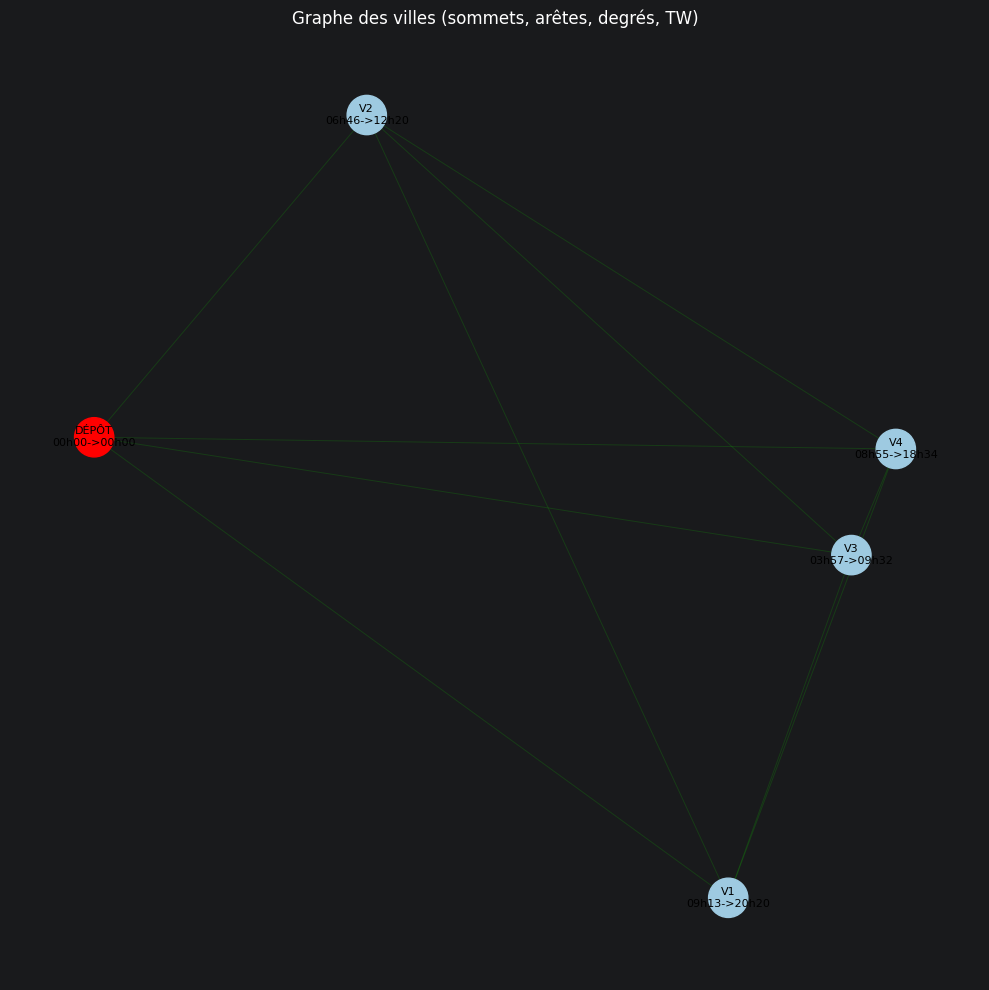

In [5]:
import networkx as nx
import matplotlib.pyplot as plt
from sys import maxsize

G = nx.Graph()

# Sommets (villes)
for i, (x, y) in enumerate(coordonnees_villes):
    G.add_node(i, pos=(x, y), fenetre=liste_villes[i])

# Listes pour les arêtes ouvertes et bloquées
edges_open = []
edges_blocked = []

# Arêtes (routes)
for i in range(NB_VILLES):
    for j in range(i + 1, NB_VILLES):
        if matrice[i][j] < maxsize:
            G.add_edge(i, j, weight=int(matrice[i][j]))
            edges_open.append((i, j))
        else:
            edges_blocked.append((i, j))

# Vérification graphe complet
degres = dict(G.degree())
est_complet = (
    G.number_of_edges() == NB_VILLES * (NB_VILLES - 1) // 2
    and all(d == NB_VILLES - 1 for d in degres.values())
)

print("Nombre de sommets  :", G.number_of_nodes())
print("Nombre d'arêtes    :", G.number_of_edges())
print("Degrés des sommets :", degres)
print("Graphe complet     :", est_complet)

pos = nx.get_node_attributes(G, "pos")
node_labels = {
    i: f"DÉPÔT\n{to_hhmm(liste_villes[i][0])}->{to_hhmm(liste_villes[i][1])}" if i == 0 
    else f"V{i}\n{to_hhmm(liste_villes[i][0])}->{to_hhmm(liste_villes[i][1])}"
    for i in G.nodes()
}

# mettre v0 en rouge car elle represente le dépot
node_colors = ["#9ecae1" if i != 0 else "#ff0000" for i in G.nodes()]

plt.figure(figsize=(10, 10))

# Nœuds
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=800)

# Arêtes ouvertes (vert)
nx.draw_networkx_edges(
    G, pos, 
    edgelist=edges_open, 
    edge_color="#11D100", 
    width=0.7, 
    alpha=0.18
)

# Arêtes bloquées (rouge pointillé)
nx.draw_networkx_edges(
    G, pos, 
    edgelist=edges_blocked, 
    edge_color="#FF0000", 
    width=0.7, 
    alpha=0.5, 
    style="dashed" # pointilé
)

nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8)

plt.title("Graphe des villes (sommets, arêtes, degrés, TW)")
plt.axis("off")
plt.tight_layout()
plt.show()

## X. Recherche préalable de la solution optimale
Afin d'avoir l'optimum global et permettre de vérifier les performances et la qualité des solutions données par notre méta-heuristique, nous allons utiliser le solveur PuLP.

In [6]:
from pulp import *
import numpy as np

# --- 1. Paramétrage ---
NB_VILLES = len(matrice)
range_villes = range(NB_VILLES)

MINUTES_PAR_JOUR = 1440
MAX_TIME = MINUTES_PAR_JOUR * 10 # Autorise une tournée jusqu'à 10 jours
M_solveur = MAX_TIME * 2 # Doit être strictement supérieur à MAX_TIME

# --- 2. Initialisation du modèle ---
prob = LpProblem("TSPTW_Final", LpMinimize)

# Variables de décision
x = LpVariable.dicts("x", (range_villes, range_villes), 0, 1, LpBinary)
T = LpVariable.dicts("T", range_villes, lowBound=0, upBound=MAX_TIME)
A = LpVariable.dicts("A", range_villes, lowBound=0, upBound=MAX_TIME)
k = LpVariable.dicts("k", range_villes, lowBound=0, cat="Integer")
y = LpVariable.dicts("y", range_villes, 0, 1, LpBinary)

A_return = LpVariable("A_return", lowBound=0, upBound=MAX_TIME)

# --- 3. Fonction objectif ---
# On ne somme que les routes existantes (non bloquées)
prob += lpSum(matrice[i][j] * x[i][j] for i in range_villes for j in range_villes if i != j and matrice[i][j] < 1000000)

# --- 4. Contraintes Structurelles ---
for i in range_villes:
    prob += x[i][i] == 0 # Pas de boucle sur soi-même

    # Interdiction stricte d'emprunter les routes bloquées
    for j in range_villes:
        if matrice[i][j] >= 1000000:
            prob += x[i][j] == 0

# Chaque ville est QUITTÉE exactement une fois
for i in range_villes:
    prob += lpSum(x[i][j] for j in range_villes if i != j) == 1

# Chaque ville est VISITÉE exactement une fois
for j in range_villes:
    prob += lpSum(x[i][j] for i in range_villes if i != j) == 1

# Initialisation Dépôt (Ville 0)
prob += T[0] == 0
prob += A[0] == 0
prob += k[0] == 0
prob += y[0] == 1

# --- 5. Fenêtres Temporelles ---
for i in range_villes:
    e_i, l_i = liste_villes[i]
    prob += T[i] >= A[i]

    if i != 0:
        prob += T[i] >= e_i + MINUTES_PAR_JOUR * k[i]
        prob += T[i] <= l_i + MINUTES_PAR_JOUR * k[i]

        prob += T[i] <= A[i] + M_solveur * (1 - y[i])
        prob += T[i] <= e_i + MINUTES_PAR_JOUR * k[i] + M_solveur * y[i]

# --- 6. MTZ Étendue ---
for i in range_villes:
    for j in range_villes:
        # On applique la contrainte UNIQUEMENT si la route n'est pas bloquée
        if i != j and matrice[i][j] < 1000000:
            if j != 0:
                prob += A[j] >= T[i] + matrice[i][j] - M_solveur * (1 - x[i][j])
            else:
                prob += A_return >= T[i] + matrice[i][0] - M_solveur * (1 - x[i][0])

# --- 7. Résolution ---
prob.solve(PULP_CBC_CMD(msg=0))

# --- 8. Affichage ---
print("Status :", LpStatus[prob.status])
if LpStatus[prob.status] == "Optimal":
    print("Coût total (Distance) :", value(prob.objective))
    print("Heure de retour final au dépôt :", value(A_return), "minutes")

    chemin = []
    current = 0
    # Sécurité pour éviter les boucles infinies dans l'affichage
    for _ in range_villes:
        for j in range_villes:
            if value(x[current][j]) > 0.5:
                chemin.append((current, j))
                current = j
                break

    print("Chemin :", chemin)
    print("Arrivées (A) :", {i: f"{int(value(A[i]))}min" for i in range_villes})
    print("Services (T) :", {i: f"{int(value(T[i]))}min" for i in range_villes})
    print("Jours (k) :", {i: int(value(k[i])) for i in range_villes})
else:
    print("Le problème est impossible. Tes fenêtres temporelles ou tes routes bloquées isolent une ville.")

Status : Optimal
Coût total (Distance) : 1825.0
Heure de retour final au dépôt : 14400.0 minutes
Chemin : [(0, 2), (2, 4), (4, 3), (3, 1), (1, 0)]
Arrivées (A) : {0: '0min', 1: '2034min', 2: '406min', 3: '1677min', 4: '838min'}
Services (T) : {0: '0min', 1: '2034min', 2: '406min', 3: '1677min', 4: '838min'}
Jours (k) : {0: 0, 1: 1, 2: 0, 3: 1, 4: 0}


## 2. Instanciation des algorithmes

## 3. Plan d'expérience

Étude statistique (et pistes d'amélioration si on veut)

# Conclusion